In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline

# Baseline Figures Comparison

In [3]:
# Experiment Name and Locations
fridge = "xld1000sl"
amp = "hemt"
wire = "cu"

exp = "ff-fc-delft-"+ amp + "_" + wire + "-" + fridge
fname = PROJ_ROOT_PATH / "notebooks" / "experiments" / fridge / amp / exp / f"{exp}.pkl"
pqfname =  PROJ_ROOT_PATH / "notebooks" / "experiments" / fridge / amp / exp  / f"PQ_{exp}.pkl"
df =  pd.read_pickle(fname)
df_pq =  pd.read_pickle(pqfname)
pq = df_pq.iloc[0].tolist()
title = "Baseline Configuration with XLD1000sl"

In [4]:
from library.utils import fontstyle, style_map

title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Define fallbacks (only used if a stack tuple isn’t in style_map)
# fallback_colors = plt.cm.tab20.colors  # a nice, long qualitative palette
# fallback_hatches = ['/', '\\', 'x', '-', '+', 'o', 'O', '.', '*']  # repeats cyclically
fallback_color = 'white' 
fallback_hatch = '//'  

/tmp/ipykernel_99464/3403298208.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


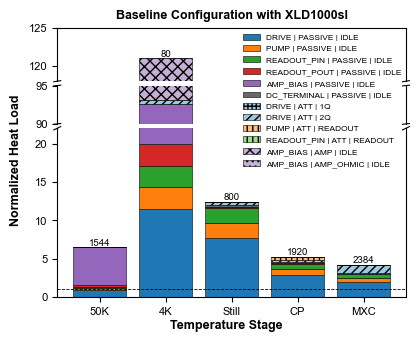

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# User controls: TWO breaks
# -----------------------------
y1_low  = 22    # top of bottom axis
y1_high = 90    # bottom of middle axis (gap #1 is (y1_low, y1_high))

y2_low  = 95   # top of middle axis
y2_high = 118   # bottom of top axis (gap #2 is (y2_low, y2_high))

y_top_max = 125

# Visible spans (for equal scale)
span_bot = y1_low - 0
span_mid = y2_low - y1_high
span_top = y_top_max - y2_high

fig = plt.figure(figsize=(4.5, 3.5))
gs = fig.add_gridspec(
    3, 1,
    height_ratios=[span_top, span_mid, span_bot],  # IMPORTANT: proportional spans => same scale
    hspace=0.05
)

ax_top = fig.add_subplot(gs[0])
ax_mid = fig.add_subplot(gs[1], sharex=ax_top)
ax_bot = fig.add_subplot(gs[2], sharex=ax_top)

# -----------------------------
# Your data setup (unchanged)
# -----------------------------
df_plot = df
possible_physical_qubits = pq
cols = list(df_plot.columns)

x = np.arange(len(df_plot.index))
xticklabels = ["50K", "4K", "Still", "CP", "MXC"]

totals = df_plot.sum(axis=1).astype(float).values

def draw_stacked(ax):
    bottom = np.zeros(len(x), dtype=float)
    for col in cols:
        values = df_plot[col].astype(float).values
        style = style_map.get(col, {})
        color = style.get("color", fallback_color)
        hatch = style.get("hatch", fallback_hatch)
        label = f"{col[0]} | {col[1]} | {col[2]}"

        bars = ax.bar(
            x, values, bottom=bottom, label=label,
            color=color, edgecolor="black", linewidth=0.4
        )
        for b in bars:
            b.set_hatch(hatch)
        bottom += values

    ax.axhline(y=1, color="k", linestyle="--", linewidth=0.6)

# Draw on all three axes
draw_stacked(ax_top)
draw_stacked(ax_mid)
draw_stacked(ax_bot)

# -----------------------------
# Apply limits (the two breaks)
# -----------------------------
ax_bot.set_ylim(0, y1_low)
ax_mid.set_ylim(y1_high, y2_low)
ax_top.set_ylim(y2_high, y_top_max)

# -----------------------------
# Annotations (place exactly once)
# -----------------------------
for i, total in enumerate(totals):
    txt = f"{possible_physical_qubits[i]}"

    if total <= y1_low:
        ax_bot.text(i, total, txt, ha="center", va="bottom", fontproperties=text_font)

    elif y1_high <= total <= y2_low:
        ax_mid.text(i, total, txt, ha="center", va="bottom", fontproperties=text_font)

    elif total >= y2_high:
        ax_top.text(i, total, txt, ha="center", va="bottom", fontproperties=text_font)

    else:
        # Total falls into a hidden gap; pin it to the nearest visible boundary.
        # Gap #1: (y1_low, y1_high)
        if y1_low < total < y1_high:
            ax_bot.text(i, y1_low, txt, ha="center", va="bottom", fontproperties=text_font)
        # Gap #2: (y2_low, y2_high)
        elif y2_low < total < y2_high:
            ax_mid.text(i, y2_low, txt, ha="center", va="bottom", fontproperties=text_font)

# -----------------------------
# Hide internal spines + x tick labels except bottom
# -----------------------------
ax_top.spines["bottom"].set_visible(False)
ax_mid.spines["top"].set_visible(False)
ax_mid.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)

ax_top.tick_params(bottom=False, labelbottom=False)
ax_mid.tick_params(bottom=False, labelbottom=False)

# -----------------------------
# Break marks: between top<->mid AND mid<->bot
# -----------------------------
d = 0.01

def break_marks(ax_upper, ax_lower):
    # on bottom of upper
    kw = dict(transform=ax_upper.transAxes, color="k", clip_on=False, linewidth=0.8)
    ax_upper.plot((-d, +d), (-d, +d), **kw)
    ax_upper.plot((1 - d, 1 + d), (-d, +d), **kw)
    # on top of lower
    kw = dict(transform=ax_lower.transAxes, color="k", clip_on=False, linewidth=0.8)
    ax_lower.plot((-d, +d), (1 - d, 1 + d), **kw)
    ax_lower.plot((1 - d, 1 + d), (1 - d, 1 + d), **kw)

break_marks(ax_top, ax_mid)
break_marks(ax_mid, ax_bot)

# -----------------------------
# Cosmetics (as before)
# -----------------------------
ax_top.set_title(title, fontproperties=axis_label_font)

ax_bot.set_xticks(x)
ax_bot.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)

for ax in (ax_top, ax_mid, ax_bot):
    for label in ax.get_yticklabels():
        label.set_fontproperties(tick_label_font)

handles, labels = ax_bot.get_legend_handles_labels()
fig.legend(
    handles, labels,
    ncol=1, bbox_to_anchor=(0.53, 0.87), loc="upper left",
    prop=legend_font, frameon=False, borderaxespad=0.0
)

fig.supxlabel("Temperature Stage", fontproperties=axis_label_font)
fig.supylabel("Normalized Heat Load", fontproperties=axis_label_font)

plt.tight_layout()
# plt.savefig("./baseline-xld1000sl.png", dpi=600, bbox_inches="tight")


/tmp/ipykernel_99464/1659328503.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


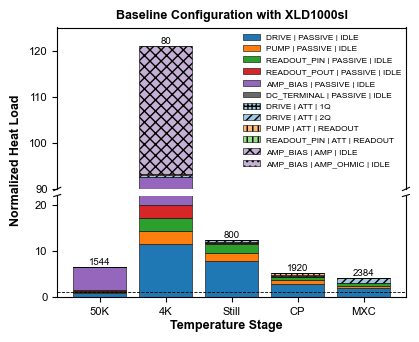

In [10]:
# -----------------------------
# User controls for the break
# -----------------------------
y_break_low  = 22  # top of the lower axis
y_break_high = 90# bottom of the upper axis
# (choose these so the "interesting" bars are in [0, y_break_low]
#  and the outlier sits above y_break_high)
y_top_max = 125 # the max height

lower_span = y_break_low - 0
upper_span = y_top_max - y_break_high

fig = plt.figure(figsize=(4.5, 3.5))
gs = fig.add_gridspec(
    2, 1,
    height_ratios=[upper_span, lower_span],
    hspace=0.05
)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)


df_plot = df
possible_physical_qubits = pq
cols = list(df_plot.columns)

x = np.arange(len(df_plot.index))
xticklabels = ["50K", "4K", "Still", "CP", "MXC"]

# Precompute totals once (used for ylim + annotation decisions)
totals = df_plot.sum(axis=1).astype(float).values

def draw_stacked(ax):
    bottom = np.zeros(len(x), dtype=float)
    for col in cols:
        values = df_plot[col].astype(float).values
        style = style_map.get(col, {})
        color = style.get("color", fallback_color)
        hatch = style.get("hatch", fallback_hatch)
        label = f"{col[0]} | {col[1]} | {col[2]}"

        bars = ax.bar(
            x, values, bottom=bottom, label=label,
            color=color, edgecolor="black", linewidth=0.4
        )
        for b in bars:
            b.set_hatch(hatch)
        bottom += values

    # Keep your reference line on both axes
    ax.axhline(y=1, color="k", linestyle="--", linewidth=0.6)

# Draw identical content on both axes
draw_stacked(ax_top)
draw_stacked(ax_bot)

# -----------------------------
# Annotations (avoid duplicates)
# -----------------------------
for i, total in enumerate(totals):
    txt = f"{possible_physical_qubits[i]}"

    if total <= y_break_low:
        ax_bot.text(i, total, txt, ha="center", va="bottom", fontproperties=text_font)
    elif total >= y_break_high:
        ax_top.text(i, total, txt, ha="center", va="bottom", fontproperties=text_font)
    else:
        # bar top falls in the hidden gap; put label just above the lower limit
        ax_bot.text(i, y_break_low, txt, ha="center", va="bottom", fontproperties=text_font)

# -----------------------------
# Limits: the actual "break"
# -----------------------------
# y_top_max = float(np.max(totals) * 1.1)
ax_bot.set_ylim(0, y_break_low)
ax_top.set_ylim(y_break_high, y_top_max)

# Hide spines between axes + x tick labels on top
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False)
plt.setp(ax_top.get_xticklabels(), visible=False)

# Diagonal break marks
d = 0.01  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=0.8)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# -----------------------------
# Cosmetics: apply to both axes
# -----------------------------

ax_top.set_title(title, fontproperties=axis_label_font)

ax_bot.set_xticks(x)
ax_bot.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)

for ax in (ax_top, ax_bot):
    for label in ax.get_yticklabels():
        label.set_fontproperties(tick_label_font)

# Legend: pull from one axis (they’re identical)
handles, labels = ax_bot.get_legend_handles_labels()
fig.legend(
    handles, labels,
    ncol=1, bbox_to_anchor=(0.53, 0.87), loc="upper left",
    prop=legend_font, frameon=False, borderaxespad=0.0
)

fig.supxlabel("Temperature Stage", fontproperties=axis_label_font)
fig.supylabel("Normalized Heat Load", fontproperties=axis_label_font)

plt.tight_layout()
# plt.savefig("./baseline-xld1000sl.png", dpi=600, bbox_inches="tight")


/tmp/ipykernel_99464/1644401281.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


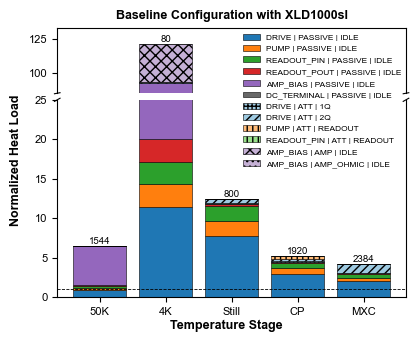

In [6]:
from matplotlib.ticker import MultipleLocator

# -----------------------------
# User controls for the break
# -----------------------------
y_break_low  = 25  # top of the lower axis
y_break_high = 85# bottom of the upper axis
# (choose these so the "interesting" bars are in [0, y_break_low]
#  and the outlier sits above y_break_high)

fig = plt.figure(figsize=(4.5, 3.5))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 3], hspace=0.05)
ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)

df_plot = df
possible_physical_qubits = pq
cols = list(df_plot.columns)

x = np.arange(len(df_plot.index))
xticklabels = ["50K", "4K", "Still", "CP", "MXC"]

# Precompute totals once (used for ylim + annotation decisions)
totals = df_plot.sum(axis=1).astype(float).values

def draw_stacked(ax):
    bottom = np.zeros(len(x), dtype=float)
    for col in cols:
        values = df_plot[col].astype(float).values
        style = style_map.get(col, {})
        color = style.get("color", fallback_color)
        hatch = style.get("hatch", fallback_hatch)
        label = f"{col[0]} | {col[1]} | {col[2]}"

        bars = ax.bar(
            x, values, bottom=bottom, label=label,
            color=color, edgecolor="black", linewidth=0.4
        )
        for b in bars:
            b.set_hatch(hatch)
        bottom += values

    # Keep your reference line on both axes
    ax.axhline(y=1, color="k", linestyle="--", linewidth=0.6)

# Draw identical content on both axes
draw_stacked(ax_top)
draw_stacked(ax_bot)

# -----------------------------
# Annotations (avoid duplicates)
# -----------------------------
for i, total in enumerate(totals):
    txt = f"{possible_physical_qubits[i]}"

    if total <= y_break_low:
        ax_bot.text(i, total, txt, ha="center", va="bottom", fontproperties=text_font)
    elif total >= y_break_high:
        ax_top.text(i, total, txt, ha="center", va="bottom", fontproperties=text_font)
    else:
        # bar top falls in the hidden gap; put label just above the lower limit
        ax_bot.text(i, y_break_low, txt, ha="center", va="bottom", fontproperties=text_font)

# -----------------------------
# Limits: the actual "break"
# -----------------------------
y_top_max = float(np.max(totals) * 1.1)
ax_bot.set_ylim(0, y_break_low)
ax_top.set_ylim(y_break_high, y_top_max)

# Hide spines between axes + x tick labels on top
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False)
plt.setp(ax_top.get_xticklabels(), visible=False)

# Diagonal break marks
d = 0.008  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=0.8)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# -----------------------------
# Cosmetics: apply to both axes
# -----------------------------

ax_top.set_title(title, fontproperties=axis_label_font)

ax_bot.set_xticks(x)
ax_bot.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)

for ax in (ax_top, ax_bot):
    for label in ax.get_yticklabels():
        label.set_fontproperties(tick_label_font)

# Legend: pull from one axis (they’re identical)
handles, labels = ax_bot.get_legend_handles_labels()
fig.legend(
    handles, labels,
    ncol=1, bbox_to_anchor=(0.53, 0.87), loc="upper left",
    prop=legend_font, frameon=False, borderaxespad=0.0
)

fig.supxlabel("Temperature Stage", fontproperties=axis_label_font)
fig.supylabel("Normalized Heat Load", fontproperties=axis_label_font)

plt.tight_layout()
# plt.savefig("./baseline-xld1000sl.png", dpi=600, bbox_inches="tight")


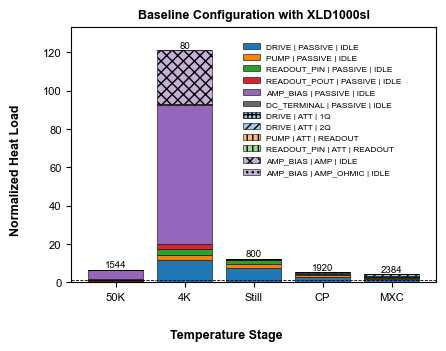

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4.5, 3.5))

df_plot = df
possible_physical_qubits = pq
title = title

# Columns: MultiIndex with levels (Cable, Component, Operation)
cols = list(df_plot.columns)

# Index: temperature stages (e.g., "4K", "Still", "CP", "MXC")
# X positions and labels (temperature stages)
x = np.arange(len(df_plot.index))
xticklabels = ["50K", "4K", "Still", "CP", "MXC" ]

# Create the figure/axes

# Build the stacked bars
bottom = np.zeros(len(x), dtype=float)

for i, col in enumerate(cols):
    values = df_plot[col].astype(float).values

    # pull style from style_map if present, else fallback
    style = style_map.get(col, {})
    color = style.get('color', fallback_color)
    hatch = style.get('hatch', fallback_hatch)

    # readable label in legend
    label = f"{col[0]} | {col[1]} | {col[2]}"

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor='black',
        linewidth=0.4
    )
    # apply hatch to each rectangle
    for b in bars:
        b.set_hatch(hatch)

    bottom += values  # update stack baseline


# Display no. of supported qubits on top of the bar
totals = df_plot.sum(axis=1)  # Sum over column. Get bar height
for i, total in enumerate(totals):
    ax.text(i, total, f'{possible_physical_qubits[i]}', ha='center', va='bottom', fontproperties=text_font)

# Draw horizantal line at y=1
ax.axhline(y=1, color='k', linestyle='--',linewidth=0.6)

# Axis cosmetics
# Set titles 
ax.set_title(title, fontproperties=axis_label_font)
# ax.set_xlabel("Temperature Stage", fontproperties=axis_label_font)
# ax.set_ylabel("Normalized Heat Load", fontproperties=axis_label_font)
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)
for label in ax.get_yticklabels() :
    label.set_fontproperties(tick_label_font)
ax.set_ylim(0, max(totals)*1.1) # Set max y-value to be slightly higher than the tallest bar

# Legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
          ncol=1, 
          bbox_to_anchor=(0.53, 0.87), 
          loc='upper left',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

# Axis Labels
fig.supxlabel('Temperature Stage',fontproperties=axis_label_font)
fig.supylabel('Normalized Heat Load', fontproperties=axis_label_font)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Save figure
plt.savefig(f"./baseline-xld1000sl.png",dpi=600,bbox_inches='tight')